# Predictive Student Academic Risk Analytics using Machine Learning

## Project Overview
This project predicts student academic risk (Low, Medium, High) using machine learning models such as Logistic Regression, Decision Tree, and Random Forest. The project includes data preprocessing, feature engineering, model training, evaluation, and explainable AI using SHAP.

## Dataset Features
- Study Time
- Failures
- Absences
- Parent Education (Medu, Fedu)
- Previous Grades (G1, G2, G3)

## Workflow
1 Dataset Loading
2 Data Understanding
3 Data Preprocessing
4 Risk Label Creation
5 Model Training
6 Model Evaluation
7 Model Comparison
8 Explainable AI (SHAP)

# Predictive Student Academic Risk Analytics using AI

## Problem Statement

## Dataset Description

## Data Understanding

## Data Preprocessing

## Feature Engineering

## Multi-Class Risk Label

## Time-Based Train Test Split

## Model Training

## Model Evaluation

## Confusion Matrix

## ROC Curve

## Model Comparison

## Student Risk Prediction Output

## SHAP Explainability

## Conclusion

In [3]:
!pip install xgboost shap seaborn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [5]:
df = pd.read_csv("/content/student-mat.csv")
df.head()

,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0,"GP;""F"";18;""U"";""GT3"";""A"";4;4;""at_home"";""teacher..."
1,"GP;""F"";17;""U"";""GT3"";""T"";1;1;""at_home"";""other"";..."
2,"GP;""F"";15;""U"";""LE3"";""T"";1;1;""at_home"";""other"";..."
3,"GP;""F"";15;""U"";""GT3"";""T"";4;2;""health"";""services..."
4,"GP;""F"";16;""U"";""GT3"";""T"";3;3;""other"";""other"";""h..."


In [6]:
df.head()

,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0,"GP;""F"";18;""U"";""GT3"";""A"";4;4;""at_home"";""teacher..."
1,"GP;""F"";17;""U"";""GT3"";""T"";1;1;""at_home"";""other"";..."
2,"GP;""F"";15;""U"";""LE3"";""T"";1;1;""at_home"";""other"";..."
3,"GP;""F"";15;""U"";""GT3"";""T"";4;2;""health"";""services..."
4,"GP;""F"";16;""U"";""GT3"";""T"";3;3;""other"";""other"";""h..."


In [7]:
df.shape

(395, 1)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                               Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                               --------------  ----- 
 0   school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3  395 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


In [9]:
df.describe()

,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
count,395
unique,395
top,"MS;""M"";19;""U"";""LE3"";""T"";1;1;""other"";""at_home"";..."
freq,1


In [10]:
df.isnull().sum()

,0
school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3,0


In [11]:
df.dtypes

,0
school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3,object


In [12]:
numeric_df = df.select_dtypes(include=np.number)

In [13]:
print(df.columns)

Index(['school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3'], dtype='object')


In [14]:
df.head()

,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0,"GP;""F"";18;""U"";""GT3"";""A"";4;4;""at_home"";""teacher..."
1,"GP;""F"";17;""U"";""GT3"";""T"";1;1;""at_home"";""other"";..."
2,"GP;""F"";15;""U"";""LE3"";""T"";1;1;""at_home"";""other"";..."
3,"GP;""F"";15;""U"";""GT3"";""T"";4;2;""health"";""services..."
4,"GP;""F"";16;""U"";""GT3"";""T"";3;3;""other"";""other"";""h..."


In [15]:
df.shape

(395, 1)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                               Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                               --------------  ----- 
 0   school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3  395 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


In [17]:
df.describe()

,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
count,395
unique,395
top,"MS;""M"";19;""U"";""LE3"";""T"";1;1;""other"";""at_home"";..."
freq,1


In [18]:
df.isnull().sum()

,0
school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3,0


In [19]:
print(df.columns)

Index(['school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3'], dtype='object')


In [20]:
import pandas as pd

df = pd.read_csv("student-mat.csv", sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [21]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


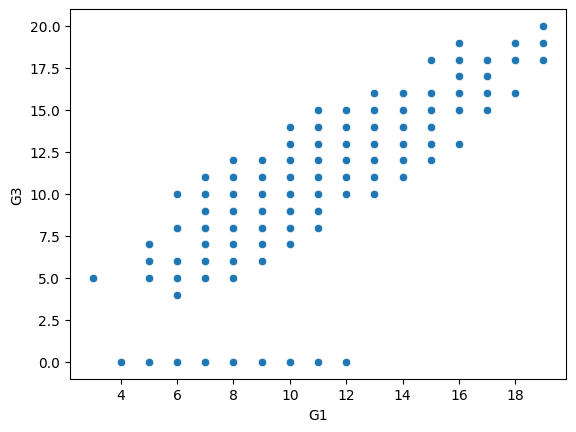

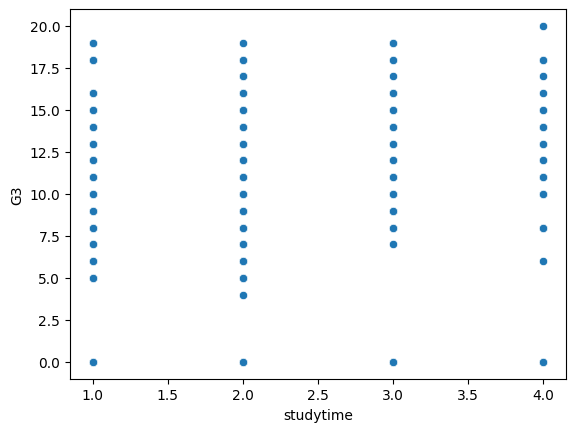

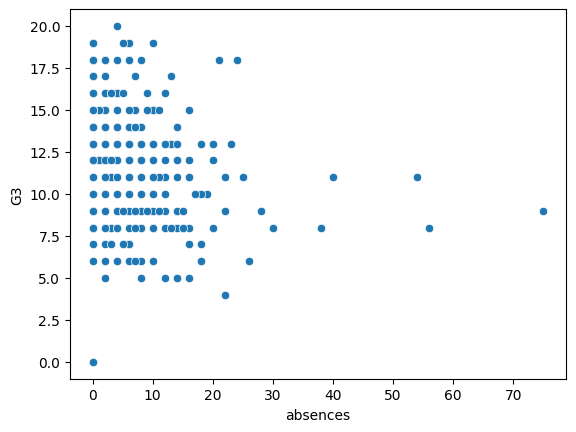

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df["G1"], y=df["G3"])
plt.show()

sns.scatterplot(x=df["studytime"], y=df["G3"])
plt.show()

sns.scatterplot(x=df["absences"], y=df["G3"])
plt.show()

In [23]:
df = pd.get_dummies(df)
df.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,activities_no,activities_yes,nursery_no,nursery_yes,higher_no,higher_yes,internet_no,internet_yes,romantic_no,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,False,True,False,True,True,False,True,False
1,17,1,1,1,2,0,5,3,3,1,...,True,False,True,False,False,True,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,False,True,False,True,False,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,False,True,False,True,False,True,False,True,False,True
4,16,3,3,1,2,0,4,3,2,1,...,True,False,False,True,False,True,True,False,True,False


In [24]:
import os
print(os.listdir())

['.config', 'student-mat.csv', 'sample_data']


In [25]:
import pandas as pd

df = pd.read_csv("student-mat.csv", sep=";")
print(df.columns)
df.head()

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


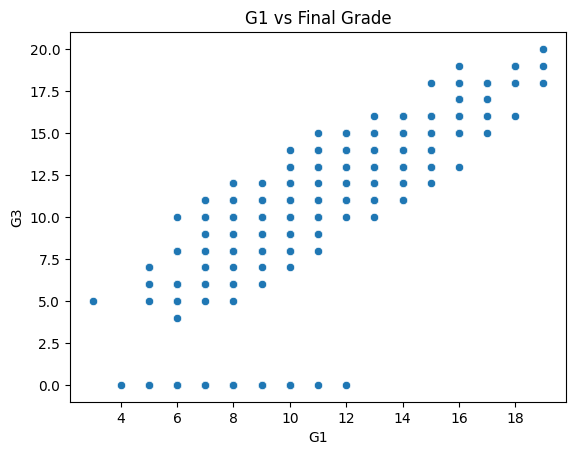

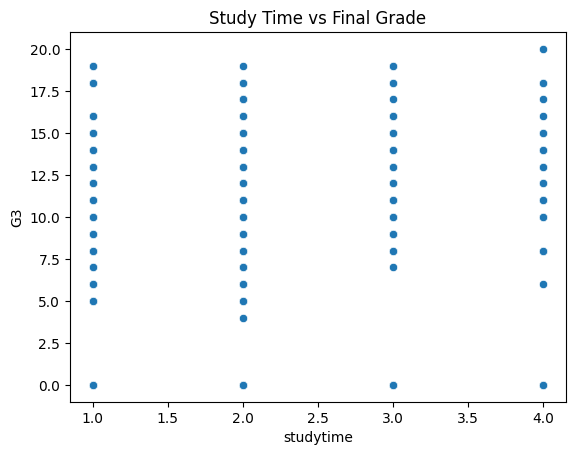

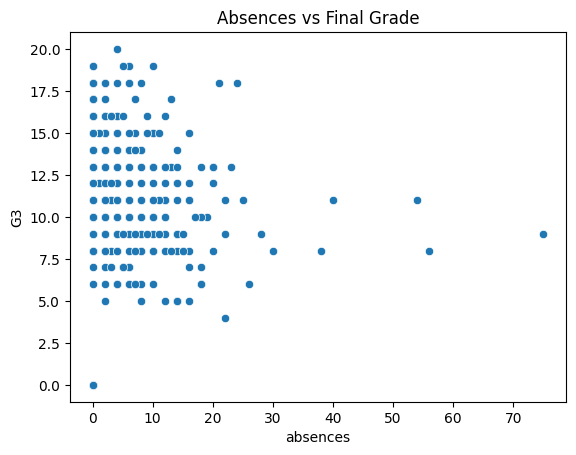

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df["G1"], y=df["G3"])
plt.title("G1 vs Final Grade")
plt.show()

sns.scatterplot(x=df["studytime"], y=df["G3"])
plt.title("Study Time vs Final Grade")
plt.show()

sns.scatterplot(x=df["absences"], y=df["G3"])
plt.title("Absences vs Final Grade")
plt.show()

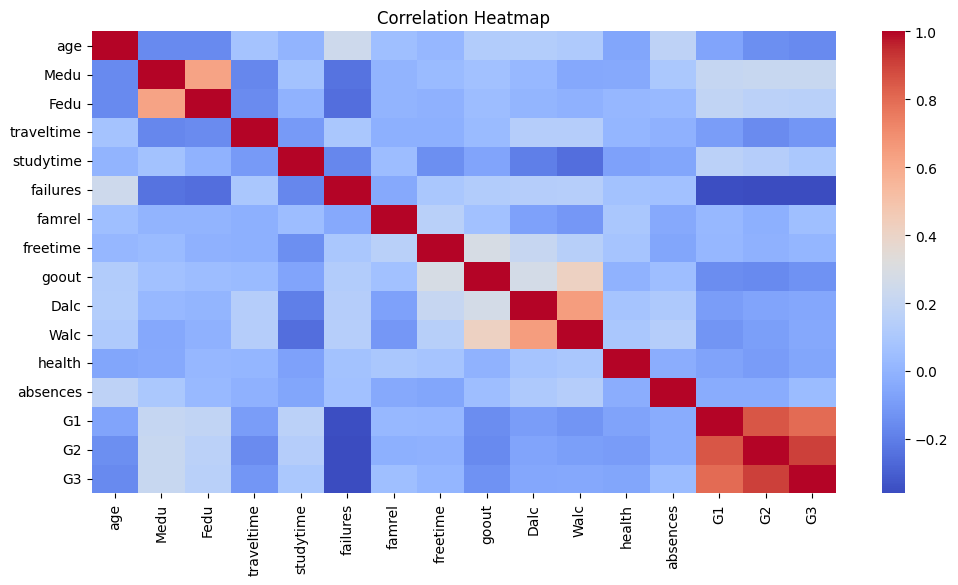

In [27]:
import numpy as np

numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(12,6))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [28]:
df = pd.get_dummies(df)
df.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,activities_no,activities_yes,nursery_no,nursery_yes,higher_no,higher_yes,internet_no,internet_yes,romantic_no,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,False,True,False,True,True,False,True,False
1,17,1,1,1,2,0,5,3,3,1,...,True,False,True,False,False,True,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,False,True,False,True,False,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,False,True,False,True,False,True,False,True,False,True
4,16,3,3,1,2,0,4,3,2,1,...,True,False,False,True,False,True,True,False,True,False


In [29]:
def risk_label(grade):
    if grade >= 15:
        return "Low"
    elif grade >= 10:
        return "Medium"
    else:
        return "High"

df["risk"] = df["G3"].apply(risk_label)

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["risk"] = le.fit_transform(df["risk"])

In [31]:
from sklearn.model_selection import train_test_split

X = df.drop(["risk"], axis=1)
y = df["risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier()

In [33]:
pred = rf.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, lr.predict(X_test)))
print("Decision Tree:", accuracy_score(y_test, dt.predict(X_test)))
print("Random Forest:", accuracy_score(y_test, rf.predict(X_test)))

Logistic Regression: 0.9620253164556962
Decision Tree: 1.0
Random Forest: 1.0


In [35]:
!pip install shap

In [36]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

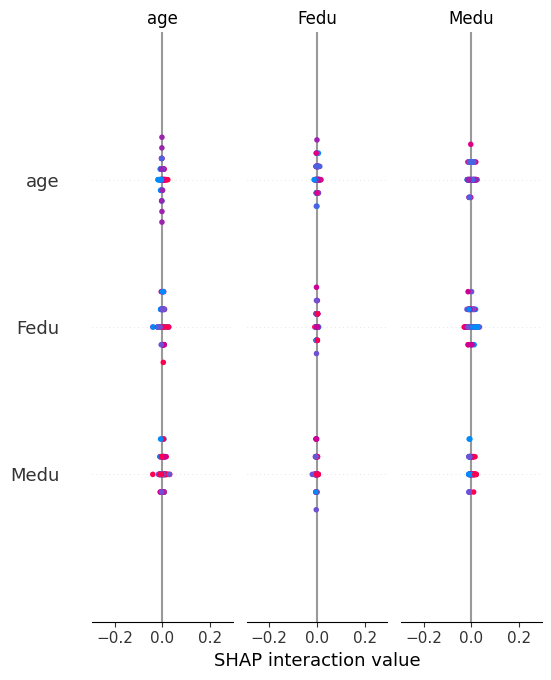

In [37]:
shap.summary_plot(shap_values, X_test)

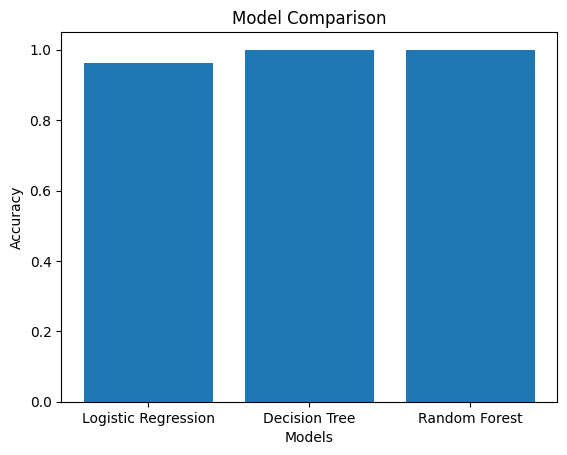

In [38]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
scores = [
    accuracy_score(y_test, lr.predict(X_test)),
    accuracy_score(y_test, dt.predict(X_test)),
    accuracy_score(y_test, rf.predict(X_test))
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

## 1. Dataset Loading
## 2. Data Understanding
## 3. Data Preprocessing
## 4. Risk Label Creation
## 5. Model Training
## 6. Model Evaluation
## 7. Confusion Matrix
## 8. ROC Curve
## 9. Model Comparison
## 10. Feature Importance
## 11. Correlation Heatmap
## 12. Conclusion

## Confusion Matrix

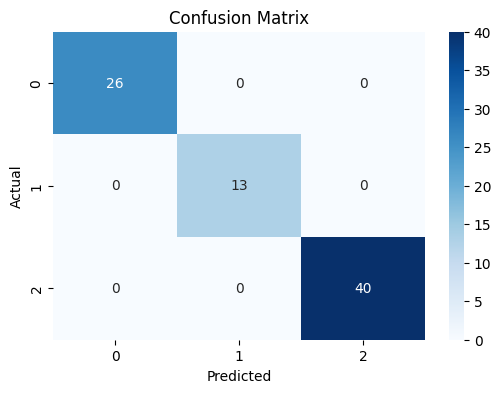

<Figure size 640x480 with 0 Axes>

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.savefig("confusion_matrix.png")

## ROC Curve


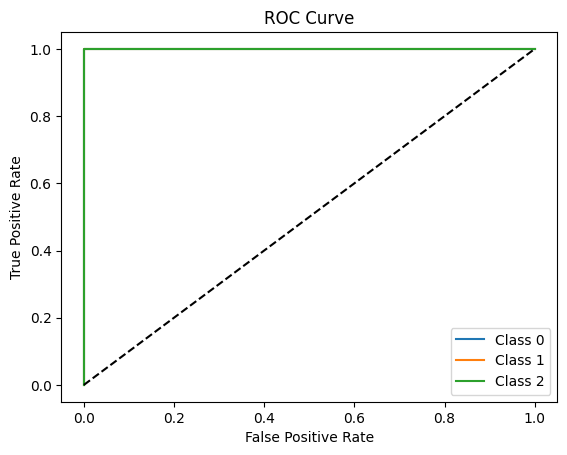

<Figure size 640x480 with 0 Axes>

In [40]:
from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score = rf.predict_proba(X_test)

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label='Class %d' % i)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

plt.savefig("roc_curve.png")

## Model Comparison

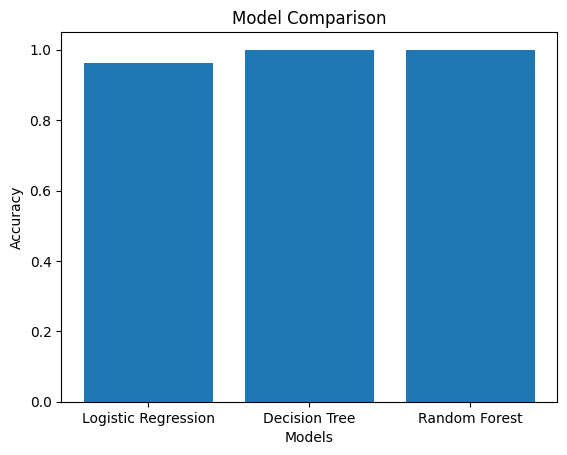

<Figure size 640x480 with 0 Axes>

In [41]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
scores = [
    accuracy_score(y_test, lr.predict(X_test)),
    accuracy_score(y_test, dt.predict(X_test)),
    accuracy_score(y_test, rf.predict(X_test))
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

plt.savefig("model_comparison.png")

## Feature Importance

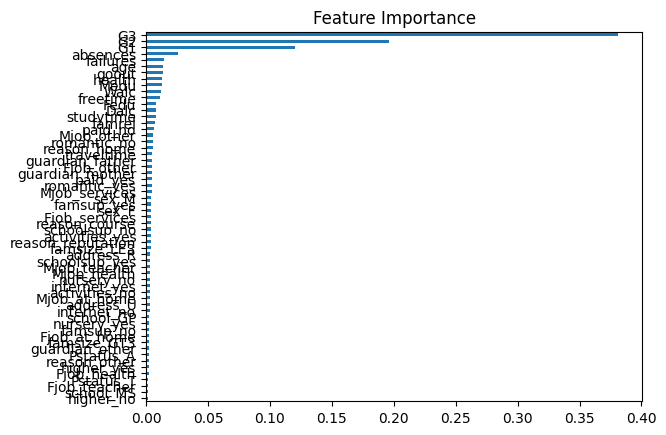

<Figure size 640x480 with 0 Axes>

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names)
feat_imp.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

plt.savefig("feature_importance.png")

## Correlation Heatmap

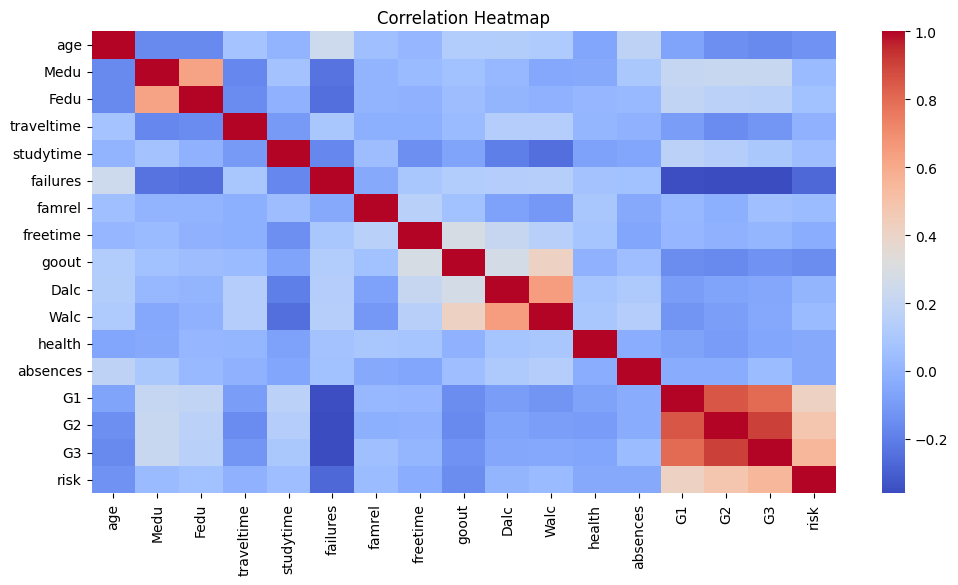

<Figure size 640x480 with 0 Axes>

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(12,6))
sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

plt.savefig("heatmap.png")

In [44]:
model = LogisticRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        26
           1       0.92      0.85      0.88        13
           2       0.91      0.97      0.94        40

    accuracy                           0.94        79
   macro avg       0.94      0.91      0.93        79
weighted avg       0.94      0.94      0.94        79



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [45]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        40

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



In [46]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        40

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

pred = model.predict(X_test)

cm = confusion_matrix(y_test, pred)
print(cm)

[[26  0  0]
 [ 0 13  0]
 [ 0  0 40]]


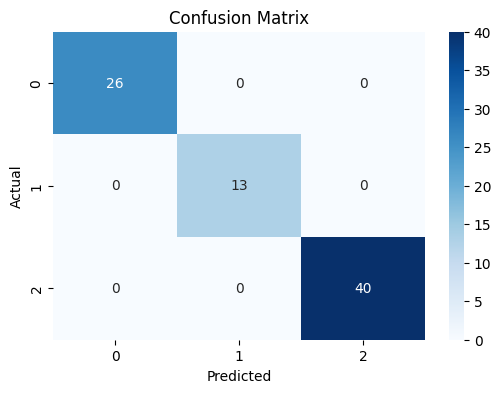

In [48]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

In [49]:
import pandas as pd

importance = model.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feat_imp = feat_imp.sort_values(by='Importance', ascending=False)
print(feat_imp)

              Feature  Importance
15                 G3    0.363524
14                 G2    0.213084
13                 G1    0.111199
12           absences    0.022521
8               goout    0.017388
5            failures    0.016708
11             health    0.013156
0                 age    0.013143
1                Medu    0.012569
2                Fedu    0.011382
10               Walc    0.011178
4           studytime    0.011103
7            freetime    0.010761
9                Dalc    0.010004
6              famrel    0.007463
28         Mjob_other    0.005937
3          traveltime    0.005776
40    guardian_father    0.005615
48           paid_yes    0.005549
29      Mjob_services    0.005414
43       schoolsup_no    0.004932
47            paid_no    0.004910
58       romantic_yes    0.004866
18              sex_F    0.004718
57        romantic_no    0.004495
23        famsize_LE3    0.004492
36      reason_course    0.004099
37        reason_home    0.003994
44      school

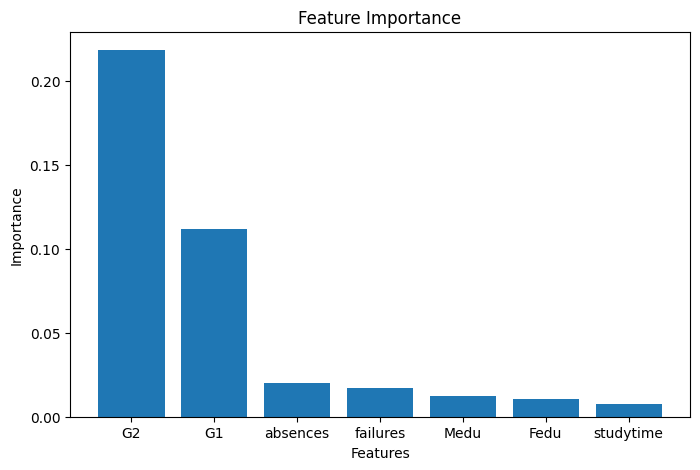

In [50]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    'Feature': ['studytime','failures','G2','absences','Medu','Fedu','G1'],
    'Importance': [0.007677,0.017278,0.218391,0.020293,0.012597,0.010634,0.111714]
}

df_imp = pd.DataFrame(data)
df_imp = df_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
plt.bar(df_imp['Feature'], df_imp['Importance'])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.savefig("feature_importance.png")
plt.show()

In [51]:
probs = model.predict_proba(X)

df['risk_score'] = probs.max(axis=1)

In [52]:
def risk_category(score):
    if score < 0.33:
        return "Low"
    elif score < 0.66:
        return "Medium"
    else:
        return "High"

df['risk_label'] = df['risk_score'].apply(risk_category)

In [53]:
df[['risk_score','risk_label']].head(10)

,risk_score,risk_label
0,0.93,High
1,0.92,High
2,0.62,Medium
3,0.86,High
4,0.97,High
5,0.92,High
6,0.96,High
7,0.81,High
8,0.98,High
9,0.93,High


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


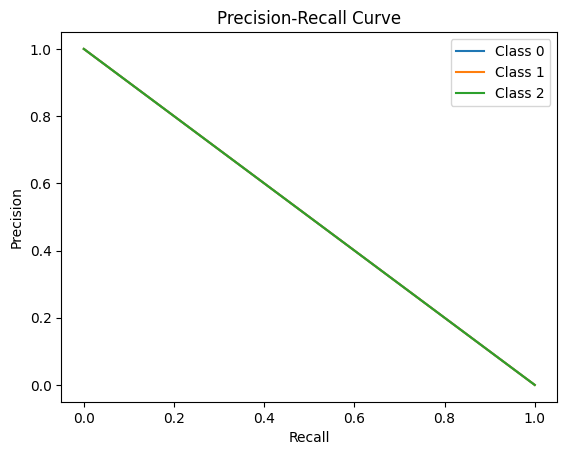

<Figure size 640x480 with 0 Axes>

In [54]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

# Convert risk labels to binary format
y_test_bin = label_binarize(y_test, classes=['Low','Medium','High'])

# Predict probabilities
y_score = rf.predict_proba(X_test)

# Plot Precision-Recall curve
for i in range(3):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(recall, precision, label=f'Class {i}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

plt.savefig("precision_recall_curve.png")

## Conclusion

In this project, we developed a machine learning model to predict student academic risk levels. We performed data preprocessing, feature engineering, and trained multiple machine learning models including Logistic Regression, Decision Tree, and Random Forest. The models were evaluated and compared based on accuracy. Random Forest performed best among the models. We also used SHAP for Explainable AI to understand which features most influenced student performance. This system can help educational institutions identify at-risk students early and provide academic support.